<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/sec-comment-letters/download-sec-comment-letters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download and Analyze SEC Comment Letters

In this tutorial, you will learn how to find and download SEC Comment Letters from EDGAR and perform analysis on these filings.

The tutorial consists of the following steps:

1. Retrieving SEC Comment Letter URLs: Utilize the Query API to search and gather all URLs of SEC Comment Letters available on EDGAR, creating a comprehensive list.
2. Downloading Comment Letters: Use the Render API to download all Comment Letters as .TXT files and save them to your local disk for further analysis.
3. Analysis: In this tutorial, we will demonstrate how to analyze the distribution of comment letters over EDGAR form types in the year 2021. Additionally, you will learn how to perform topic modeling using BERTopic.




## Introduction to SEC Comment Letters

SEC Comment letters are official correspondence issued by the U.S. Securities and Exchange Commission (SEC) to companies in response to their filed disclosure documents, such as annual reports (Form 10-K), quarterly reports (Form 10-Q), and registration statements (Form S-1). These letters are part of the SEC's review and comment process, which aims to ensure compliance with securities regulations and promote transparent and accurate financial reporting. They provide valuable insights into the SEC's concerns, highlight areas of potential risk, and give investors a better understanding of the company's financial disclosures and accounting practices.

When the SEC reviews a company's disclosure documents, they may identify issues, concerns, or requests for additional information. These findings are communicated to the company through Comment letters, also known as SEC Staff Letters. The letters highlight specific areas where the SEC believes further clarification, disclosure, or revision is necessary.

SEC Comment letters typically address various aspects of the company's financial statements, accounting practices, disclosures, risk factors, legal compliance, internal controls, executive compensation, and other matters relevant to public disclosure. The letters are intended to help the company enhance the quality and accuracy of its public filings and ensure compliance with applicable securities laws and regulations.

Upon receiving a Comment letter, the company is required to respond to each comment, either by providing the requested information, clarifying existing disclosures, or justifying its position. The response is either submitted as an amendment or an updated filing to the original document or as separate new letter to the SEC staff. The SEC may then review the company's response and provide further guidance or request additional revisions if necessary. The resolution of comments may involve multiple rounds of letters exchanged between the SEC staff and the filer.

Comment letters and the company's responses are published on the EDGAR system starting from August 1, 2004. The SEC issues Comment letters for various EDGAR filings. The most common types of filings that may trigger SEC Comment letters include:

- **Annual and Quarterly Reports** (10-K, 10-Q, etc.): Companies are required to file annual and quarterly reports that provide a comprehensive overview of their financial performance, business operations, risk factors, and other relevant information. The SEC may issue Comment letters to seek clarification or request additional disclosures regarding the company's financial statements, accounting practices, significant transactions, and other areas of concern.
- **Registration Statements** (S-1, S-3, etc.): When a company plans to offer securities to the public, it must file a registration statement with the SEC. These filings provide detailed information about the company, its business, and the securities being offered. The SEC may issue Comment letters during the registration review process to ensure compliance with disclosure requirements and address any concerns or deficiencies identified in the filing.
- **Proxy Statements** (DEF 14A, etc.): Proxy statements are filed when a company seeks shareholder approval on matters such as elections of directors, executive compensation, and mergers. The SEC may issue Comment letters to seek clarification or request revisions regarding the information provided in the proxy statement to ensure it is accurate and complete.
- **Offering Statements** (Form 1-A, Form 1-K, etc.): Companies conducting offerings under Regulation A or Regulation CF must file offering statements with the SEC.
- **Others** (8-K, 13F, Form 4, 14D-9, etc.): The SEC may issue Comment letters for various other filings made by companies, such as current reports (Form 8-K), periodic reports by institutional investment managers (Form 13F), reports by insiders (Form 4), and filings related to mergers and acquisitions (Schedule 14D-9, Schedule TO, etc.).

It's important to note that the SEC's review and comment process is not a guarantee of the accuracy or quality of a company's financial statements. It is primarily a regulatory oversight mechanism aimed at promoting transparency and maintaining fair and efficient markets.

### EDGAR Form Types of SEC Comment Letters

There are two EDGAR form types associated with SEC Comment letters and responses: `UPLOAD` and `CORRESP`.

The `UPLOAD` form type is used for SEC-originated letters sent to filers, while the `CORRESP` form type is used for filer response letters to SEC staff that are not part of amended filings.

There is sometimes confusion between the `UPLOAD` and `LETTER` types, but they actually refer to the same thing. The `UPLOAD` form type represents the type of the form, while `LETTER` is the name of the file type that is uploaded to EDGAR. Therefore, when searching for SEC Comment letters, it is recommended to look for the file type `LETTER` instead of the `UPLOAD` form type.


### When are SEC Comment Letters released to the public?

The SEC releases Comment letters and responses no earlier than 20 business days following the completion of a filing review. Prior to January 1, 2012, the stated goal has been to release the correspondence no earlier than 45 days after the review of the disclosure filing is complete.


### Search and Find SEC Comment Letters

The Query API provides a straightforward way to search and find SEC Comment letters and responses by using the Lucene search syntax. By specifying the search expression, such as `formType:CORRESP`, the API retrieves the metadata of the matching filings, including details about the filer (CIK, ticker, filer name, etc.) and the filing itself (filing URL, filing date, filing type, exhibit URLs, etc.).

#### Find `UPLOAD`/`LETTER` Filings

To locate all SEC Comment letters of the `UPLOAD` form type, you can use the following search expression:

```
formType:LETTER
```

There is sometimes confusion between the `UPLOAD` and `LETTER` types, but they actually refer to the same thing. The `UPLOAD` form type represents the type of the form, while `LETTER` is the name of the file type that is uploaded to EDGAR. Therefore, when searching for SEC Comment letters, it is recommended to look for the file type `LETTER` instead of the `UPLOAD` form type.

When analyzing `UPLOAD` filings, there is no need to perform OCR (Optical Character Recognition) on the PDF files. Instead, you can directly download the attached `.TXT` file of the filing, which contains the complete content of the PDF in text format. This allows for easier text analysis without the need for additional conversion steps.

#### Find `CORRESP` Filings

`CORRESP` filings are usually published in HTML format and can easily be located using the following search expression:

```
formType:CORRESP
```


### Example `LETTER` Filing

Let's examine two examples of `LETTER` filings to get a better understanding of their structure and content. `LETTER` filings can range from simple notifications of the SEC's completion of a review to more complex filings that include detailed requests and comments from the SEC staff.

![Example of a Simple `LETTER` Filing](https://i.imgur.com/XpUhUzD.png)

[Source: Simple `LETTER` Filing](https://www.sec.gov/Archives/edgar/data/1860805/000000000023004540/filename1.pdf)

On the other hand, `LETTER` filings can also contain a comprehensive set of requests and comments from the SEC staff that the filer needs to address. Here's an example of a more detailed `LETTER` filing:

![Example of a Complex `LETTER` Filing](https://i.imgur.com/DqXPfTV.png)

[Source: Complex `LETTER` Filing](https://www.sec.gov/Archives/edgar/data/1485003/000000000022013176/filename1.pdf)


### Example `CORRESP` Filing

Let's also have a look at multiple examples of `CORRESP` filings.

Examples:

1. Requesting the effectiveness of a Registration Statement on Form S-3 at a specific date and time.

![CORRESP Filing - Request for Registration Statement](https://i.imgur.com/2OOG24I.png)

[Source: CORRESP Filing - Request for Registration Statement](https://www.sec.gov/Archives/edgar/data/1501756/000119312523127842/filename1.htm)

2. Inclusions of additional risk factors as discussed with the SEC.

![CORRESP EDGAR Filing Example 2](https://i.imgur.com/Rgf0E7v.png)

[Source: CORRESP Filing - Additional Risk Factors](https://www.sec.gov/Archives/edgar/data/1900402/000149315223014108/filename1.htm)

3. Request for clarification regarding whether a sponsor is controlled by a non-U.S. person. [Source Filing](https://www.sec.gov/Archives/edgar/data/1843714/000095014223001228/filename1.htm)

4. Request for providing more details about the effect on investors as a result of not having made specific arrangements, such as not utiziling an escrow account. [Source Filing](https://www.sec.gov/Archives/edgar/data/1293818/000107997323000561/filename1.htm)

5. Requesting clarification on the use of specific non-GAAP line items. [Source Filing](https://www.sec.gov/Archives/edgar/data/48898/000119312523119257/filename1.htm)







## Find SEC Comment Letters

Let's explore how to find SEC Comment letters to build up a list of URLs pointing to such letters. As an example, we will demonstrate how to locate all Comment letters published in the year 2021 using the Query API. The Lucene search expression to retrieve the metadata, including the URL, of such filings is as follows:

```
formType:LETTER AND filedAt:[2021-01-01 TO 2021-12-31]
```

To begin, install the `sec-api` package and import the necessary modules:

In [ ]:
!pip install -q sec-api

In [ ]:
API_KEY = 'YOUR_API_KEY'

In [ ]:
from sec_api import QueryApi

queryApi = QueryApi(api_key=API_KEY)

Next, create a query using the Lucene search expression to find the Comment letters published in 2021 and retrieve the filings using the Query API:

In [ ]:
query = {
  "query": "formType:LETTER AND filedAt:[2021-01-01 TO 2021-12-31]",
  "from": "0",
  "size": "200",
  "sort": [{ "filedAt": { "order": "desc" } }]
}

response = queryApi.get_filings(query)

In [ ]:
print('Number of LETTER filings published in 2021:', response['total']['value'])

Number of LETTER filings published in 2021: 9245


Finally, you can convert the metadata into a pandas DataFrame for further analysis:

In [ ]:
import pandas as pd

metadata = pd.DataFrame.from_records(response['filings'])
metadata.head(3)

,id,accessionNo,cik,ticker,companyName,companyNameLong,formType,description,filedAt,linkToTxt,linkToHtml,linkToXbrl,linkToFilingDetails,entities,documentFormatFiles,dataFiles,seriesAndClassesContractsInformation
0,b0289576de3f821a2096b306176ee195,0000000000-21-015509,1801417,BYNO,byNordic Acquisition Corp,byNordic Acquisition Corp (Filed for),LETTER,Form UPLOAD - SEC-generated letter,2021-12-31T07:30:12-05:00,https://www.sec.gov/Archives/edgar/data/180141...,https://www.sec.gov/Archives/edgar/data/180141...,,https://www.sec.gov/Archives/edgar/data/180141...,[{'companyName': 'byNordic Acquisition Corp (F...,"[{'sequence': '1', 'documentUrl': 'https://www...",[],[]
1,7f986b3cd6a3583643094da271ae7dae,0000000000-21-015508,1737995,STSS,Sharps Technology Inc.,Sharps Technology Inc. (Filed for),LETTER,Form UPLOAD - SEC-generated letter,2021-12-30T18:30:03-05:00,https://www.sec.gov/Archives/edgar/data/173799...,https://www.sec.gov/Archives/edgar/data/173799...,,https://www.sec.gov/Archives/edgar/data/173799...,[{'companyName': 'Sharps Technology Inc. (File...,"[{'sequence': '1', 'documentUrl': 'https://www...",[],[]
2,a6d2e09a2504eb0e4f9c4e75bb0b044e,0000000000-21-015503,895464,YBGJ,Yubo International Biotech Ltd,Yubo International Biotech Ltd (Filed for),LETTER,Form UPLOAD - SEC-generated letter,2021-12-30T16:30:04-05:00,https://www.sec.gov/Archives/edgar/data/895464...,https://www.sec.gov/Archives/edgar/data/895464...,,https://www.sec.gov/Archives/edgar/data/895464...,[{'companyName': 'Yubo International Biotech L...,"[{'sequence': '1', 'documentUrl': 'https://www...",[],[]


The following function `get_metadata(start_year=2021, end_year=2022)` retrieves the metadata of SEC Comment letters for a specified date range. Here's an explanation of how the function works:

1. The function iterates over the specified range of years and months to return a dataframe with metadata of SEC Comment letters.

2. Inside the nested loop, a Lucene query is constructed based on the year and month to filter the filings for that specific period.

3. Pagination is implemented using the `query_from` and `query_size` variables. The initial value of `query_from` is `0`, and `query_size` is set to `200`. These variables determine the starting index and the number of filings to retrieve in each API request.

4. A while loop is used to handle pagination. It continues until there are no more filings returned in the response.

5. Within each iteration of the while loop, a Query API request is made with the constructed query to retrieve a batch of Comment letters.

6. The retrieved filings are processed to extract the desired metadata, including the `ticker`, `cik`, `formType`, `filedAt`, `filingUrl`, and `linkToTxt` (URL of the TXT file).

7. The extracted metadata is appended to a dataframe called `df`, and any filings without a ticker symbol are filtered out. `df` is then added to a list called `frames` to store the metadata for all retrieved filings.

8. Once all years and months are processed, the `frames` list is concatenated into a single dataframe called `result`, which contains the metadata for all downloaded filings.

In [ ]:
def get_metadata(start_year=2021, end_year=2022):
  form_type_filter  = 'formType:LETTER'
  frames = []

  for year in range(start_year, end_year + 1):
    for month in range(1, 13):
      download_counter = 0
      padded_month = str(month).zfill(2) # "1" -> "01"
      date_range_filter = f'filedAt:[{year}-{padded_month}-01 TO {year}-{padded_month}-31]'
      lucene_query = date_range_filter + ' AND ' + form_type_filter

      query_from = 0
      query_size = 200

      while True:
        query = {
          "query": lucene_query,
          "from": query_from,
          "size": query_size,
          "sort": [{ "filedAt": { "order": "desc" } }]
        }

        response = queryApi.get_filings(query)
        filings = response['filings']

        if len(filings) == 0:
          break
        else:
          query_from += query_size

        metadata = list(map(lambda f: {'ticker': f['ticker'],
                                       'cik': f['cik'],
                                       'formType': f['formType'],
                                       'filedAt': f['filedAt'],
                                       'filingUrl': f['linkToFilingDetails'],
                                       'linkToTxt': f['linkToTxt']
                                      }, filings))

        df = pd.DataFrame.from_records(metadata)
        # remove all entries without a ticker symbol
        df = df[df['ticker'].str.len() > 0]
        df.loc[:, 'filingUrl'] = df['filingUrl'].apply(lambda url: url.replace('ix?doc=/', ''))
        frames.append(df)
        download_counter += len(df)

      print(f'✅ Downloaded {download_counter} metadata objects for {year}-{padded_month}')

  result = pd.concat(frames)

  print(f'✅ Download completed. Metadata downloaded for {len(result)} filings.')

  return result

In [ ]:
metadata_2021 = get_metadata(start_year=2021, end_year=2021)

✅ Downloaded 548 metadata objects for 2021-01
✅ Downloaded 590 metadata objects for 2021-02
✅ Downloaded 685 metadata objects for 2021-03
✅ Downloaded 604 metadata objects for 2021-04
✅ Downloaded 584 metadata objects for 2021-05
✅ Downloaded 666 metadata objects for 2021-06
✅ Downloaded 618 metadata objects for 2021-07
✅ Downloaded 600 metadata objects for 2021-08
✅ Downloaded 678 metadata objects for 2021-09
✅ Downloaded 586 metadata objects for 2021-10
✅ Downloaded 540 metadata objects for 2021-11
✅ Downloaded 512 metadata objects for 2021-12
✅ Download completed. Metadata downloaded for 7211 filings.


In [ ]:
metadata_2021.head(3)

,ticker,cik,formType,filedAt,filingUrl,linkToTxt
0,OWL,1823945,LETTER,2021-01-29T18:30:04-05:00,https://www.sec.gov/Archives/edgar/data/182394...,https://www.sec.gov/Archives/edgar/data/182394...
1,SIVR,1450922,LETTER,2021-01-29T17:30:06-05:00,https://www.sec.gov/Archives/edgar/data/145092...,https://www.sec.gov/Archives/edgar/data/145092...
2,IMCR,1671927,LETTER,2021-01-29T17:30:06-05:00,https://www.sec.gov/Archives/edgar/data/167192...,https://www.sec.gov/Archives/edgar/data/167192...


## Download SEC Comment Letters

In this section, we demonstrate how to download all SEC Comment letters using the Render API and `pandarallel`. The code allows for parallel downloading of up to 10 letters in text format (.TXT) at the same time. The letters are saved to the local disk in the `filings` folder, organized by company ticker.

![Example Folder with downloaded SEC Comment Letters](https://i.imgur.com/RwuDEBx.png)

The `download_content(filing_metadata)` function is used to download and process the content of each filing. It extracts the text content from the downloaded .TXT file using regular expressions and saves it to the corresponding file in the folder structure. If the download fails, the function retries up to four times before giving up.

The `number_of_workers` variable determines the number of parallel workers used for downloading. In this example, we set it to 10. The `sample` dataframe contains a subset of the metadata (500 filings in this case), and the `download_content` function is applied in parallel using `sample.parallel_apply`.

The text content of each Comment letter is also saved to `sample['content']`.



In [ ]:
!pip install -q pandarallel

In [ ]:
from sec_api import RenderApi

renderApi = RenderApi(api_key=API_KEY)

In [ ]:
import re, os, time


def download_content(filing, retry_counter=0):
  url      = filing['linkToTxt']
  ticker   = filing['ticker']
  formType = filing['formType']

  try:
    new_folder = './filings/' + ticker
    date = filing['filedAt'][:10]
    file_name = date + '_' + formType + '_' + url.split('/')[-1]
    file_path = new_folder + '/' + file_name

    if not os.path.isdir(new_folder):
      os.makedirs(new_folder)

    content = renderApi.get_filing(url)

    pattern = r"<TEXT>(.*?)</TEXT>"
    matches = re.findall(pattern, content, re.DOTALL)

    if matches:
      if '<PDF>' in matches[0]:
        extracted_text = matches[1]
      else:
        extracted_text = matches[0]

      with open(file_path, 'w') as f:
        f.write(extracted_text)

      return extracted_text
    else:
      print("No text found between <TEXT> and </TEXT>.")
      return ''

  except Exception as e:
    print(f"❌ {ticker}: download failed: {url}")
    print(f"Error: {str(e)}")

    if retry_counter < 4:
      time.sleep(2)
      return download_content(filing, retry_counter=retry_counter+1)
    else:
      return ''


filing = metadata_2021.iloc[140]
content = download_content(filing)

In [ ]:
print(content)


United States securities and exchange commission logo





                             January 25, 2021

       Mark A. Goldsmith, M.D., Ph.D.
       President and Chief Executive Officer
       Revolution Medicines, Inc.
       700 Saginaw Drive
       Redwood City, CA 94063

                                                        Re: Revolution
Medicines, Inc.
                                                            Draft Registration
Statement on Form S-1
                                                            Submitted January
21, 2021
                                                            CIK No. 0001628171

       Dear Mr. Goldsmith:

                                                        This is to advise you
that we do not intend to review your registration statement.

               We request that you publicly file your registration statement no
later than 48 hours prior
       to the requested effective date and time. Please refer to Rules 460 and
461 regardin

In [ ]:
from pandarallel import pandarallel

number_of_workers = 10
pandarallel.initialize(progress_bar=True, nb_workers=number_of_workers, verbose=0)

In [ ]:
# download a simple of 500 comment letters
sample = metadata_2021.head(500)
sample['content'] = sample.parallel_apply(download_content, axis=1)

# uncomment the line below to download all SEC comment letters
# sample = metadata_2021
# sample['content'] = metadata_2021.parallel_apply(download_content, axis=1)

print('✅ Download complete')

✅ Download complete


<ipython-input-15-8fc70936294f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample['content'] = sample.parallel_apply(download_content, axis=1)


In [ ]:
def get_directory_size(directory):
  total_size = 0

  for path, dirs, files in os.walk(directory):
    for file in files:
      file_path = os.path.join(path, file)
      total_size += os.path.getsize(file_path)

  return total_size / (1024 * 1024)


directory_path = './filings'
total_size_mb = get_directory_size(directory_path)
print(f"Total size of all downloaded SEC Comment letters: {total_size_mb:.2f} MB")

Total size of all downloaded SEC Comment letters: 2.02 MB


## Analyze SEC Comment Letters

Now that we have downloaded all SEC Comment letters, i.e. `UPLOAD` filings, we can start analyzing their content. In this section, we will explore two examples of analysis using SEC Comment letters.

**Examples**

1. Plot the distribution of the number of SEC staff comments over EDGAR form types. The x-axis represents the EDGAR form types, and the y-axis represents the number of comment letters per form type.

2. Perform topic modeling with BERTopic to identify different topics within SEC Comment letters and cluster the letters based on their topics.

### Number of SEC Comment Letters per EDGAR Form Type

To determine the EDGAR form type referred to in a comment letter, we need to extract the form type from the letter's header.

Here's an example header of a letter filing that refers to the EDGAR form type "Form S-3":


In [ ]:
sample_content = sample['content'].values[50]
print(sample_content[:800], '...')


United States securities and exchange commission logo





                          January 28, 2021

       Kyle Guse
       Chief Financial Officer and General Counsel
       ATOSSA THERAPEUTICS, INC.
       107 Spring Street
       Seattle, Washington 98104

                                                        Re: ATOSSA
THERAPEUTICS, INC.
                                                            Registration
Statement on Form S-3
                                                            Filed January 22,
2021
                                                            File No. 333-252335

       Dear Mr. Guse:

              This is to advise you that we have not reviewed and will not
review your registration
       statement.

               Please refer to Rules 460 and 461  ...


We can extract the form type by using a regular expression that looks for a match of "Statement on" for each line above the "File No." line.

In [ ]:
def extract_form_type(text):
  try:
    header_text_pattern = r".*Dear"
    header_text = re.findall(header_text_pattern, text,  re.I | re.S)
    header_text = header_text[0]

    pattern = r"(Statement .*|Form [^\s]+)"
    matches = re.findall(pattern, header_text,  re.I)
    matches = list(set(matches))
    matches = [re.sub(r'Statement (on|off)\s?', '', x, flags=re.I) for x in matches]

    return matches

  except Exception as e:
    print(e)
    return []


extract_form_type(sample_content)

['Form S-3']

In [ ]:
# Blackberry letter refers to two form types: 10-K, 10-Q
sample_content = sample['content'].values[100]
print(sample_content[:800], '...')


United States securities and exchange commission logo





                           January 26, 2021

       Steve Rai
       Chief Financial Officer
       Blackberry Limited
       2200 University Ave East
       Waterloo, ON N2K 0A7,
       Canada

                                                        Re: Blackberry Ltd.
                                                            Form 10-K for
Fiscal Year Ended February 29, 2020
                                                            Filed April 7, 2020
                                                            Form 10-Q for
Quarterly Periods Ended November 30, 2020
                                                            Filed September 24,
2020
                                                            File No. 001-38232 ...


In [ ]:
print('Form types associated with the letter sent to Blackberry:')
print(extract_form_type(sample_content))

Form types associated with the letter sent to Blackberry:
['Form 10-Q', 'Form 10-K']


By applying the `extract_form_type` function to the content of each letter, we can extract the relevant form types associated with the comment letters.

In [ ]:
sample['refers_to'] = sample['content'].parallel_apply(extract_form_type)

In [ ]:
df = sample['refers_to'].explode('refers_to')
df.reset_index(drop=True, inplace=True)
form_types = sorted(list(df.unique().astype(str)))

print('EDGAR Form Types of SEC Comment Letters:')
print('\n'.join(form_types))

EDGAR Form Types of SEC Comment Letters:
Form 1-A
Form 10
Form 10-12G
Form 10-K
Form 10-K/A
Form 10-Q
Form 20-F
Form 8-K
Form 8-K/A
Form F-1
Form F-3
Form F-4
Form S-1
Form S-11
Form S-3
Form S-4
Form SF-1
From S-1
From S-4
Schedule 14A
Schedule 14C
nan


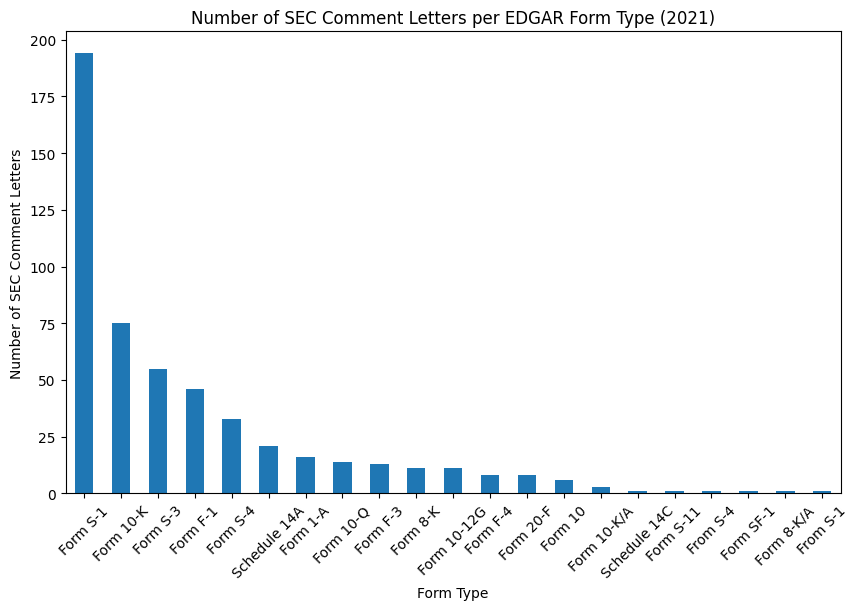

In [ ]:
import matplotlib.pyplot as plt

df = sample['refers_to'].explode('refers_to')
df.reset_index(drop=True, inplace=True)

value_counts = df.value_counts()

plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.xlabel('Form Type')
plt.ylabel('Number of SEC Comment Letters')
plt.title('Number of SEC Comment Letters per EDGAR Form Type (2021)')
plt.xticks(rotation=45)
plt.show()

### Topic Modelling of SEC Comment Letters with BERTopic

In this section, we will explore how to use BERTopic for topic modeling on SEC Comment letters. The process is divided into two main parts:

1. Text cleaning and preparation: We will remove the header text from each comment letter, eliminate stopwords such as "we," "it," and "what," and apply lemmatization to transform words to their root form. Lemmatization ensures that words with similar meanings are treated as the same word. For instance, the word "running" will be lemmatized to "run," and "better" will be lemmatized to "good."

2. Fitting BERTopic to the document corpus: We will generate embedding vectors for the SEC Comment letters and create topics using the HDBSCAN clustering algorithm. This step involves grouping similar letters into topics based on their content and context.



In [ ]:
def remove_header(letter):
  cleaned_letter = re.sub(r'.*Dear', '', letter, flags=re.S)
  return cleaned_letter


sample['cleaned_content'] = sample['content'].parallel_apply(remove_header)

In [ ]:
print('Example of a comment letter without its header')
print('----------------------------------------------')
print(sample['cleaned_content'].values[0][:1500], '...')

Example of a comment letter without its header
----------------------------------------------
 Mr. Wasserman:

              We have reviewed your registration statement and have the
following comments. In
       some of our comments, we may ask you to provide us with information so
we may better
       understand your disclosure.

              Please respond to this letter by amending your registration
statement and providing the
       requested information. If you do not believe our comments apply to your
facts and
       circumstances or do not believe an amendment is appropriate, please tell
us why in your
       response.

              After reviewing any amendment to your registration statement and
the information you
       provide in response to these comments, we may have additional comments.

       Registration Statement on From S-4 filed January 4, 2021

       Selected Definitions, page 3

   1.                                                   Please revise to
include 

In [ ]:
!pip install -q nltk

In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')

wn = nltk.WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
stopwords = nltk.corpus.stopwords.words('english')
print(f'There are {len(stopwords)} default stopwords. They are {stopwords}')

There are 179 default stopwords. They are ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'no

In [ ]:
# remove stop words
sample['content_standardized'] = sample['cleaned_content'].apply(lambda x: ' '.join([w for w in x.split() if w.lower() not in stopwords]))
# lemmatize
sample['content_standardized'] = sample['content_standardized'].apply(lambda x: ' '.join([wn.lemmatize(w) for w in x.split() if w not in stopwords]))
# remove other non-informative words
wordlist = ['please', 'page', 'comment']
sample['content_standardized'] = sample['content_standardized'].apply(lambda x: ' '.join([w for w in x.split() if w.lower() not in wordlist]))

In [ ]:
print(sample['content_standardized'].values[0][:300])

Mr. Wasserman: reviewed registration statement following comments. comments, may ask provide u information may better understand disclosure. respond letter amending registration statement providing requested information. believe apply fact circumstance believe amendment appropriate, tell u response.


In [ ]:
# docs = list(sample['cleaned_content'])
docs = list(sample['content_standardized'])

#### Vocabulary Generation

To optimize memory usage before training our model, we can pre-process our vocabulary. By creating a vocabulary of words in our dataset and setting a minimum frequency threshold, we can reduce the computational load on the tokenizer. In the code below, we generate the vocabulary by selecting words that appear at least 15 times in our data.

In [ ]:
import collections
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer

# extract vocab to be used in BERTopic
vocab = collections.Counter()
tokenizer = CountVectorizer().build_tokenizer()

for doc in tqdm(docs):
  vocab.update(tokenizer(doc))

vocab = [word for word, frequency in vocab.items() if frequency >= 15]; len(vocab)

100%|██████████| 500/500 [00:00<00:00, 8673.34it/s]


1237

#### Train BERTopic

In [ ]:
import locale
locale.getpreferredencoding = lambda: 'UTF-8'

In [ ]:
!pip install -q bertopic
from bertopic import BERTopic

In [ ]:
# source: https://colab.research.google.com/drive/1W7aEdDPxC29jP99GGZphUlqjMFFVKtBC?usp=sharing#scrollTo=DIv6fRecTvTw
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# prepare sub-models
# see here for a list of all models: https://www.sbert.net/docs/pretrained_models.html
embedding_model = SentenceTransformer('all-mpnet-base-v2')
embeddings = embedding_model.encode(docs, show_progress_bar=True)

umap_model = UMAP(n_components=5, n_neighbors=15, random_state=42, metric='cosine', verbose=True)
hdbscan_model = HDBSCAN(min_samples=20, gen_min_span_tree=True, prediction_data=False, min_cluster_size=20)
# vectorizer_model = CountVectorizer(vocabulary=vocab, stop_words="english")

# fit BERTopic without actually performing any clustering
topic_model= BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        # vectorizer_model=vectorizer_model, # causes divide by zero encountered in true_divide
        verbose=True
).fit(docs, embeddings=embeddings)

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,339,0_statement_disclosure_may_registration,"[statement, disclosure, may, registration, not...",[Mr. Balkin: reviewed registration statement f...
1,1,58,1_review_action_absence_461,"[review, action, absence, 461, acceleration, r...",[Mr. Flood: advise reviewed review registratio...
2,2,57,2_review_action_sciences_life,"[review, action, sciences, life, adequacy, acc...",[Mr. Schreiber: advise reviewed review registr...
3,3,46,3_review_action_completed_finance,"[review, action, completed, finance, adequacy,...",[Mr. Beekhuisen: completed review filing. remi...


In [ ]:
topic_model.get_topic(topic=1)

[('review', 0.16467594236548108),
 ('action', 0.15724217716679395),
 ('absence', 0.10993984620559281),
 ('461', 0.10682466720551433),
 ('acceleration', 0.10671969930903165),
 ('request', 0.10343612706686907),
 ('staff', 0.10165338949306918),
 ('advise', 0.10045037768051748),
 ('finance', 0.10039777356376828),
 ('adequacy', 0.09678466838447443)]

In [ ]:
# reduce dimensionality of embeddings
umap_model = UMAP(n_components=5, n_neighbors=15, random_state=42, metric='cosine', verbose=True)
reduced_embeddings_2d = umap_model.fit_transform(embeddings)

UMAP(angular_rp_forest=True, metric='cosine', n_components=5, random_state=42, verbose=True)
Wed Jun 14 14:38:46 2023 Construct fuzzy simplicial set
Wed Jun 14 14:38:46 2023 Finding Nearest Neighbors
Wed Jun 14 14:38:46 2023 Finished Nearest Neighbor Search
Wed Jun 14 14:38:47 2023 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

Wed Jun 14 14:38:48 2023 Finished embedding


In [ ]:
import itertools
import pandas as pd

# define colors for the visualization to iterate over
colors = itertools.cycle(['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
                          '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
                          '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
                          '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080',
                          '#ffffff', '#000000'])
color_key = {str(topic): next(colors) for topic in set(topic_model.topics_) if topic != -1}

# prepare dataframe and ignore outliers
df = pd.DataFrame({"x": reduced_embeddings_2d[:, 0], "y": reduced_embeddings_2d[:, 1], "Topic": [str(t) for t in topic_model.topics_]})
df['Length'] = [len(doc) for doc in docs]
df = df.loc[df.Topic != '-1']
df = df.loc[(df.y > -10) & (df.y < 10) & (df.x < 10) & (df.x > -10), :]
df['Topic'] = df['Topic'].astype('category')

# get centroids of clusters
mean_df = df.groupby('Topic').mean().reset_index()
mean_df.Topic = mean_df.Topic.astype(int)
mean_df = mean_df.sort_values('Topic')

In [ ]:
!pip install -q adjustText

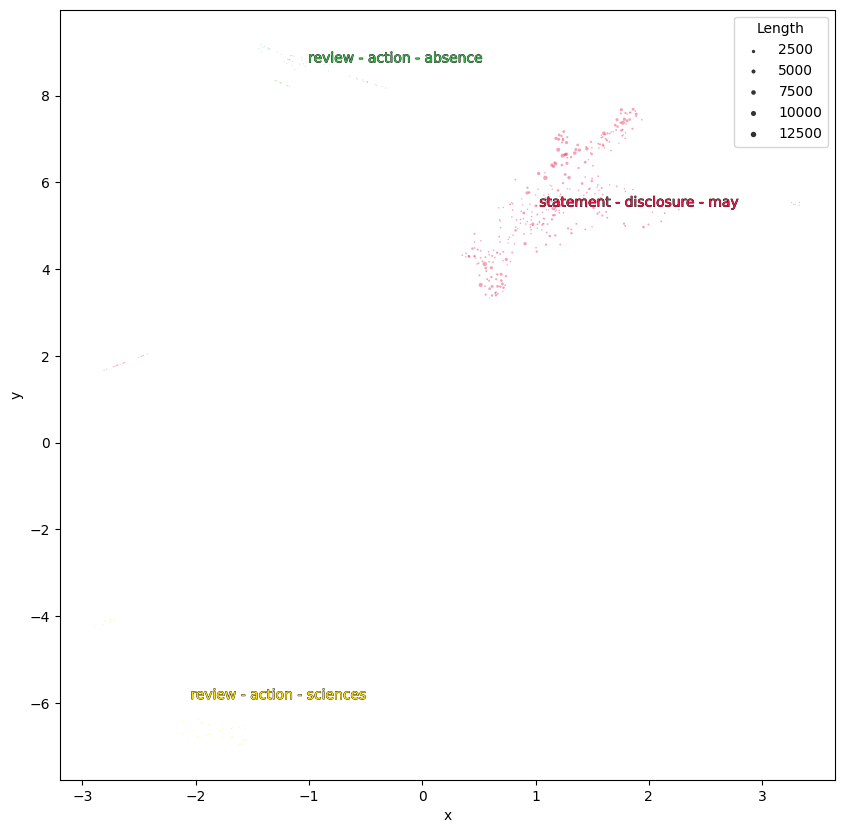

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
from adjustText import adjust_text
import matplotlib.patheffects as pe

fig = plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='x', y='y', c=df['Topic'].map(color_key), alpha=0.4, sizes=(0.4, 10), size="Length")

# annotate top 50 topics
texts, xs, ys = [], [], []
for row in mean_df.iterrows():
  topic = row[1]["Topic"]
  name = " - ".join(list(zip(*topic_model.get_topic(int(topic))))[0][:3])

  if int(topic) <= 50:
    xs.append(row[1]["x"])
    ys.append(row[1]["y"])
    texts.append(plt.text(row[1]["x"], row[1]["y"], name, size=10, ha="center", color=color_key[str(int(topic))],
                          path_effects=[pe.withStroke(linewidth=0.5, foreground="black")]))

# adjust annotations such that they do not overlap
adjust_text(texts, x=xs, y=ys, time_lim=1, force_text=(0.01, 0.02), force_static=(0.01, 0.02), force_pull=(0.5, 0.5))
plt.show()
# plt.savefig("visualization2.png", dpi=600)

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_heatmap()

## References

### SEC.gov Resources

- https://www.sec.gov/answers/commentletters.htm
- https://www.sec.gov/answers/edgarletters.htm
- https://www.sec.gov/news/press/2004-89.htm
- https://www.sec.gov/divisions/corpfin/cfannouncements/edgarcorrespondence
- https://www.sec.gov/news/press/2005-72.htm
- https://www.sec.gov/page/edgar-how-do-i-submit-correspondence-corresp
- https://www.sec.gov/divisions/corpfin/cffilingreview

### Papers

- [Causes and Consequences of Earnings Manipulation: An Analysis of Firms Subject to Enforcement Actions by the SEC](https://onlinelibrary.wiley.com/doi/10.1111/j.1911-3846.1996.tb00489.x)

### Topic Modelling

- https://github.com/MaartenGr/BERTopic
- https://maartengr.github.io/BERTopic/getting_started/quickstart/quickstart.html
- https://www.sbert.net/docs/usage/semantic_textual_similarity.html

### Other Resources

- [SEC Comment Letter Trends by PwC](https://viewpoint.pwc.com/dt/us/en/pwc/sec_comment_letters/comment_letter_trends_DM/SEC_comment_letters.html)